In [4]:
from typing import TypedDict

class MainState(TypedDict):
    user_message: str
    intent: str | None
    response: str | None
    session_id: str | None
    customer_id: int | None
    order_id: int | None
    extracted_order: dict | None
    extracted_complaint: dict | None
    tool_result: dict | None
    messages: list

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(model="gpt-4.1", temperature=0.7)

## Order Agent Lab

This section draws the order agent graph and runs a few direct notebook tests against the compiled subgraph.

D:\college\semester6\nlp\restaurant_agentic_customer_service\app\my_agent\agents\order_agent.py
['__end__', '__start__', 'ask_confirmation', 'ask_missing_info', 'calculate_summary', 'extract_order', 'final_response', 'modify_order', 'order_reasoning', 'place_order', 'validate_order']


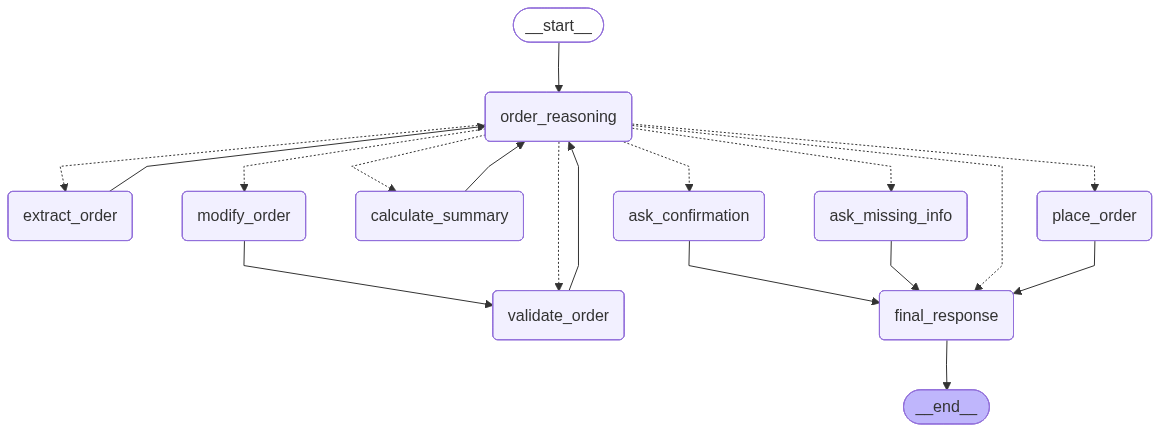

In [6]:
from pathlib import Path
import importlib
import sys

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "app").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the project root containing the app package.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

for module_name in [
    "app.my_agent.tools.order_agent_tools",
    "app.my_agent.nodes.order_agent",
    "app.my_agent.agents.order_agent",
]:
    sys.modules.pop(module_name, None)

order_tools_module = importlib.import_module("app.my_agent.tools.order_agent_tools")
order_nodes_module = importlib.import_module("app.my_agent.nodes.order_agent")
order_agent_module = importlib.import_module("app.my_agent.agents.order_agent")

order_agent_graph = order_agent_module.order_agent_graph

print(order_agent_module.__file__)
print(sorted(order_agent_graph.get_graph().nodes.keys()))
display(Image(order_agent_graph.get_graph().draw_mermaid_png()))

## Support Agent Lab

This section draws the support agent graph so you can inspect the complaint and escalation workflow visually.

D:\college\semester6\nlp\restaurant_agentic_customer_service\app\my_agent\agents\support_agent.py
['__end__', '__start__', 'ask_missing_info', 'check_order_context', 'create_ticket', 'escalate_to_human', 'extract_complaint', 'final_response', 'support_reasoning', 'validate_complaint']


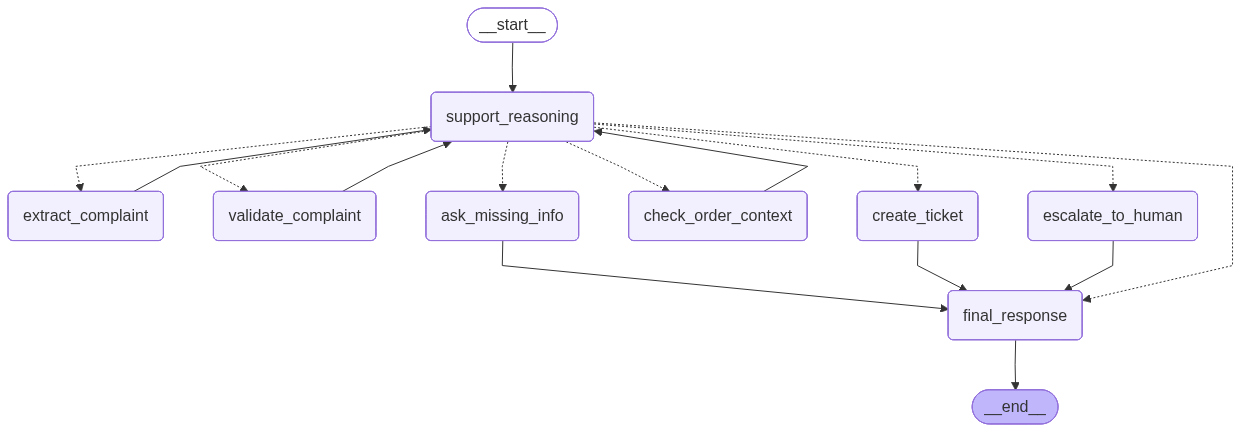

In [7]:
for module_name in [
    "app.my_agent.tools.support_agent_tools",
    "app.my_agent.nodes.support_agent_nodes",
    "app.my_agent.agents.support_agent",
]:
    sys.modules.pop(module_name, None)

support_tools_module = importlib.import_module("app.my_agent.tools.support_agent_tools")
support_nodes_module = importlib.import_module("app.my_agent.nodes.support_agent_nodes")
support_agent_module = importlib.import_module("app.my_agent.agents.support_agent")

support_agent_graph = support_agent_module.support_agent_graph

print(support_agent_module.__file__)
print(sorted(support_agent_graph.get_graph().nodes.keys()))
display(Image(support_agent_graph.get_graph().draw_mermaid_png()))